In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

from graph_generator import generator
from helpers_example import *
from globals import *
from helpers import (
    load_pickle,
    make_parameter_grid,
    split_graph,
    compute_topk_reco,
    compute_pred_metrics,
)
from bias_measures import Bias
from base_models import SVD_embedding


/Users/lilianmarey/Documents/python_repos/TMLR_submission/env_submission/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


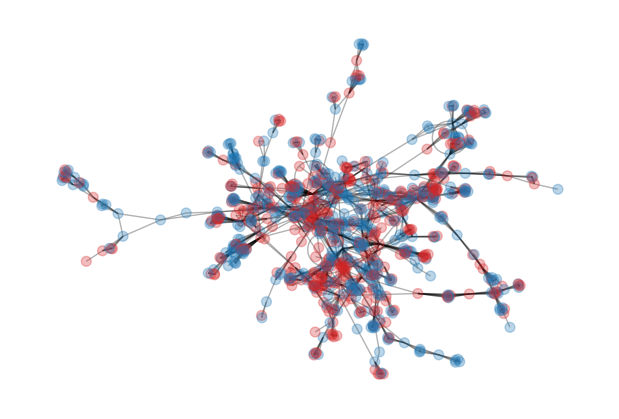

In [2]:
# Loading and drawing Collab real graph

G = load_pickle('data/collab.pkl')
k=10

plot_real_graph(G)


100%|██████████| 4/4 [00:14<00:00,  3.57s/it]


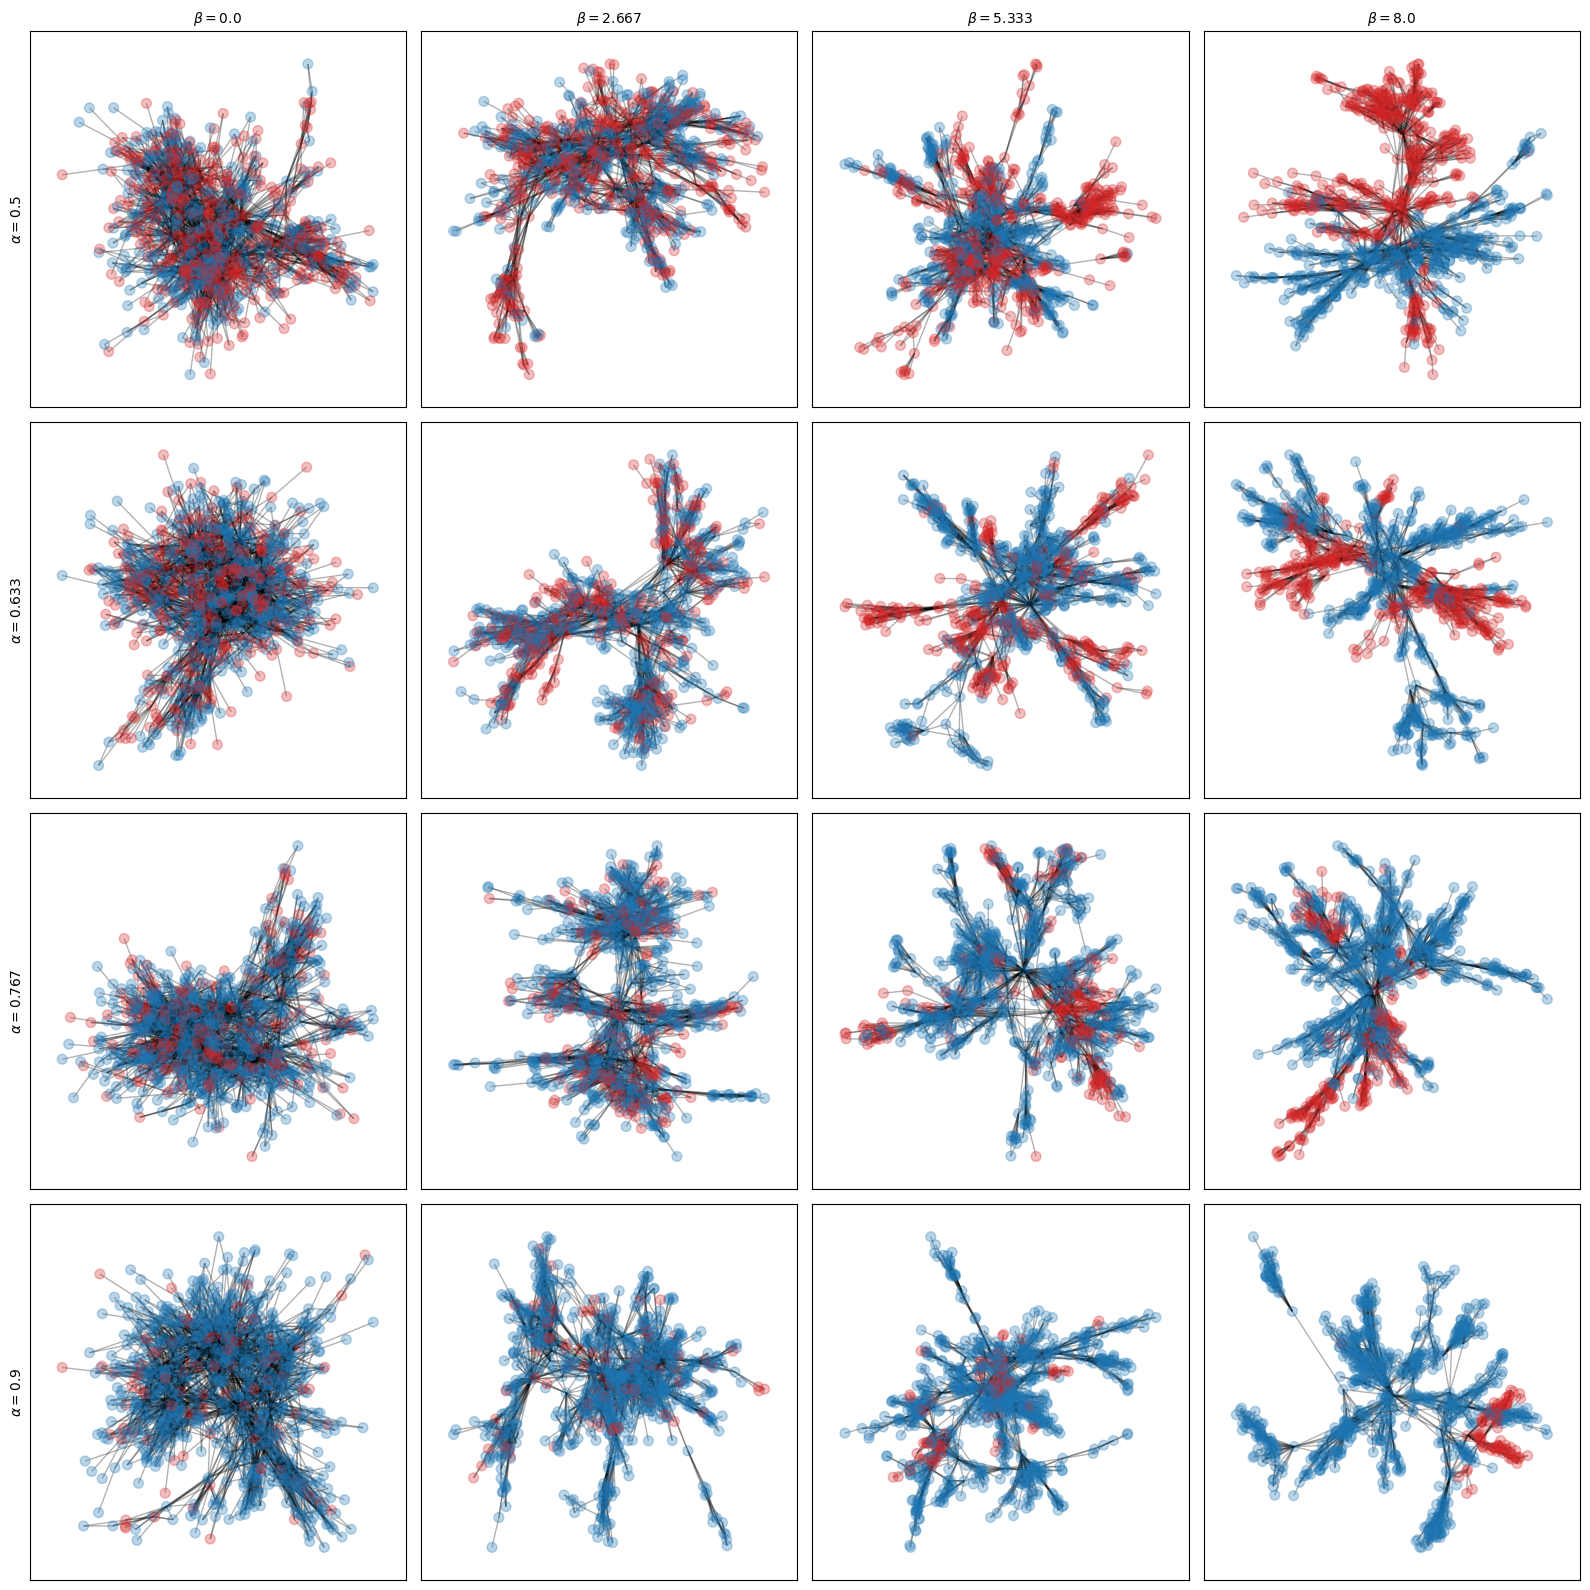

In [3]:
# Generating Collab synthetic graphs with different alpha and beta values

alpha_beta_values = make_parameter_grid(usecase="collab", n_parameter_sample=4)

graphs_dict = {
    (alpha, beta): generator(usecase="collab", alpha=alpha, beta=beta)
    for alpha, beta in tqdm(alpha_beta_values)
}
plot_graph_grid(graphs_dict)

In [4]:
# Computing bias and prediction metrics over the generated graphs

results = dict()

for (alpha, beta), G in tqdm(graphs_dict.items()):
    bias_computer = Bias(G)
    bias_values = bias_computer.compute_bias_values()
    

    G_train, test_edges = split_graph(G)
    embeddings = SVD_embedding(G_train)
    reco = compute_topk_reco(embeddings, G_train)

    pred_metrics = compute_pred_metrics(G_train, reco, test_edges, topk=k)
    results[(alpha, beta)] = pred_metrics | bias_values

df = pd.DataFrame(results).T.reset_index()
df.columns = ['alpha', 'beta'] + list(df.columns[2:])
metrics = list(df.columns[2:])

100%|██████████| 16/16 [01:08<00:00,  4.29s/it]


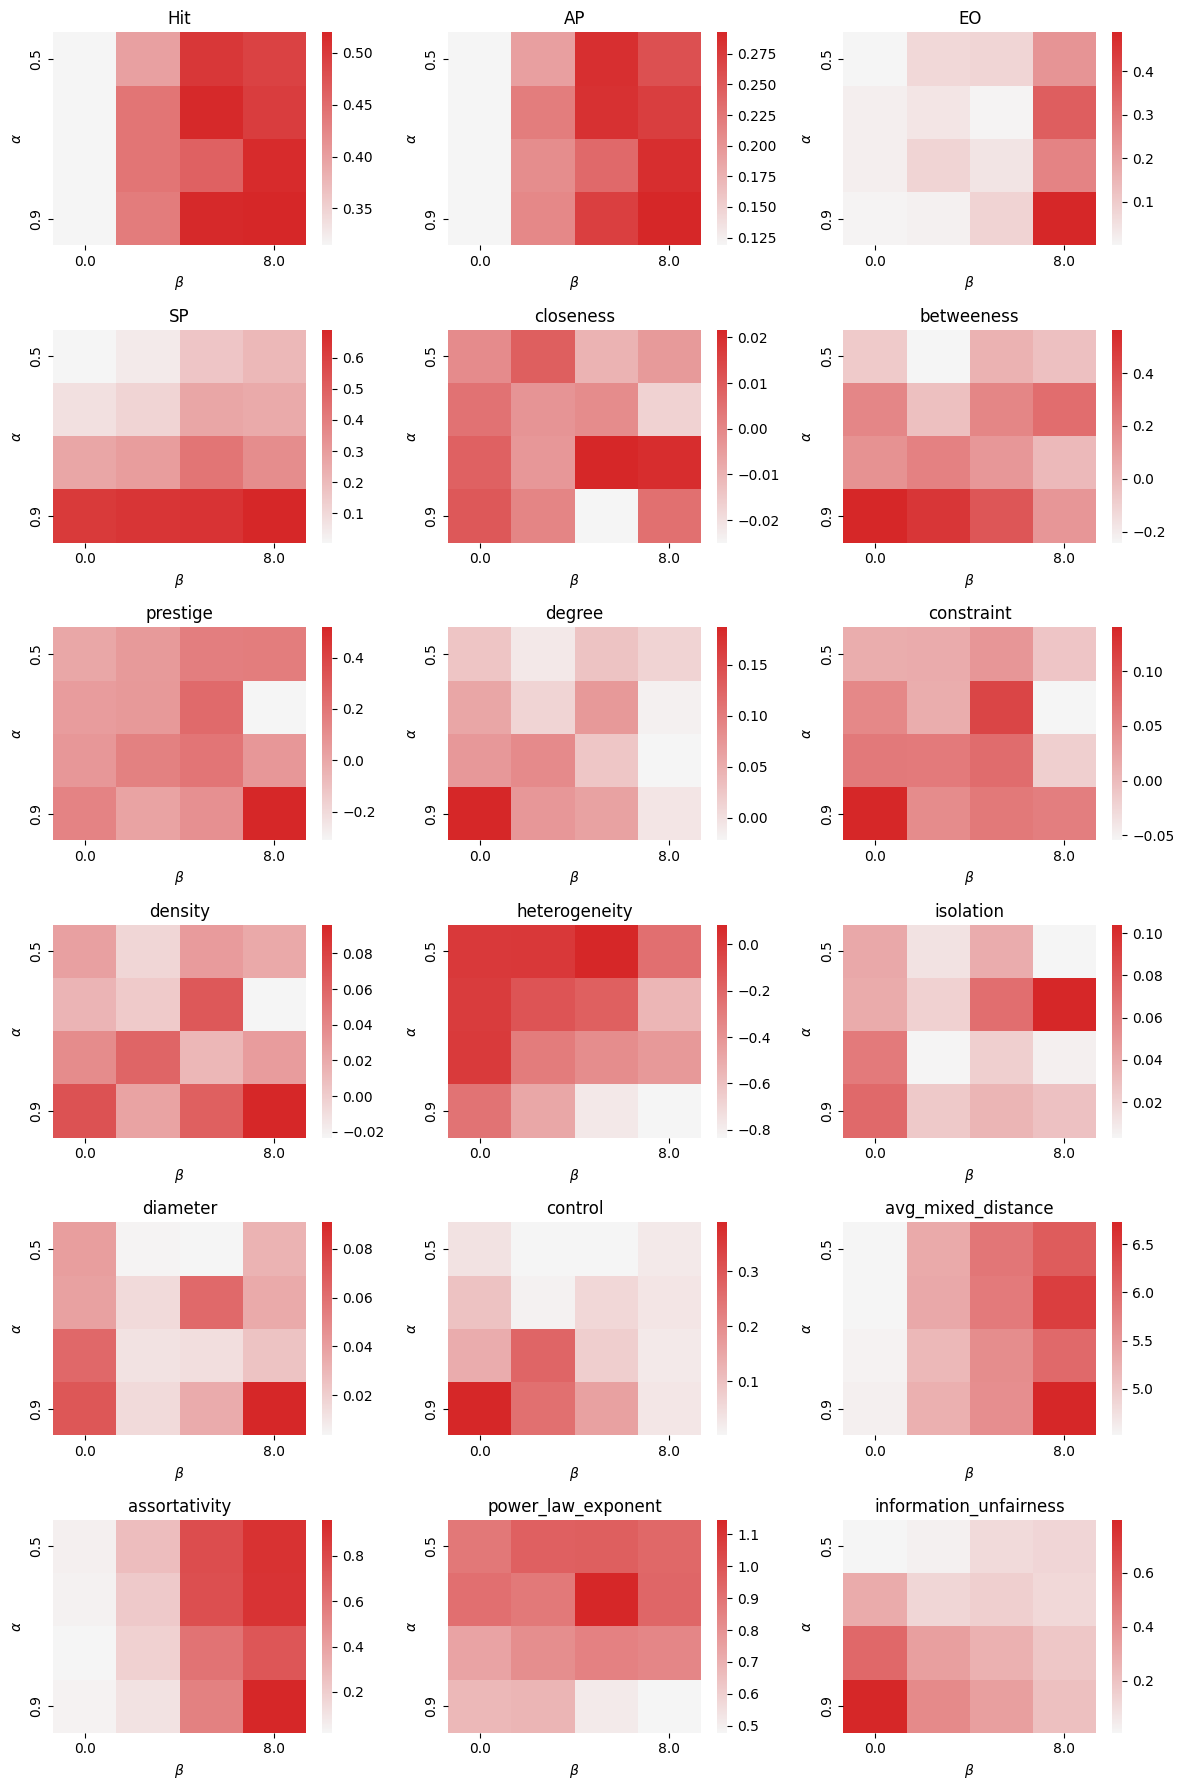

In [5]:
show_heatmaps(df, metrics)

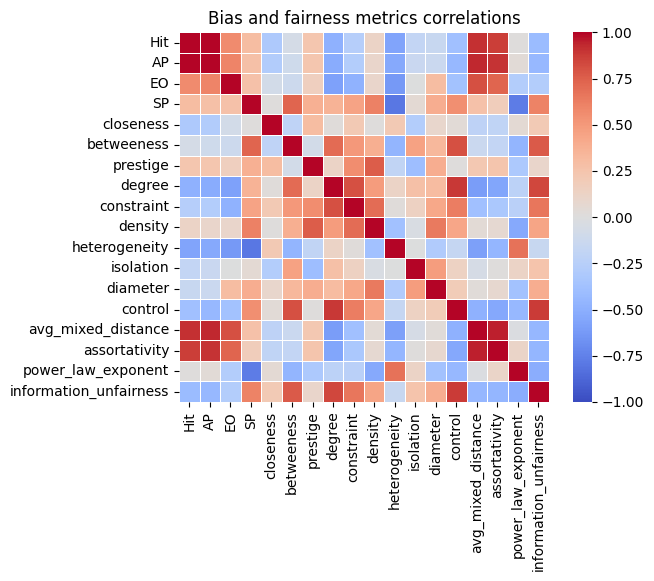

In [6]:
plot_correlations(df, metrics)

In [7]:
df_reg_SP = regression_results(df, "SP")
print("Results for regression on SP values:")
display(df_reg_SP)
df_reg_EO = regression_results(df, "EO")
print("Results for regression on EO values:")
display(df_reg_SP)

Results for regression on SP values:


,input_bias_measures,train_R2,test_R2,train_RMSE,test_RMSE
0,all_bias,0.928521,0.693502,0.059959,0.115046
1,assortativity,0.817798,0.785058,0.095728,0.277641


Results for regression on EO values:


,input_bias_measures,train_R2,test_R2,train_RMSE,test_RMSE
0,all_bias,0.928521,0.693502,0.059959,0.115046
1,assortativity,0.817798,0.785058,0.095728,0.277641


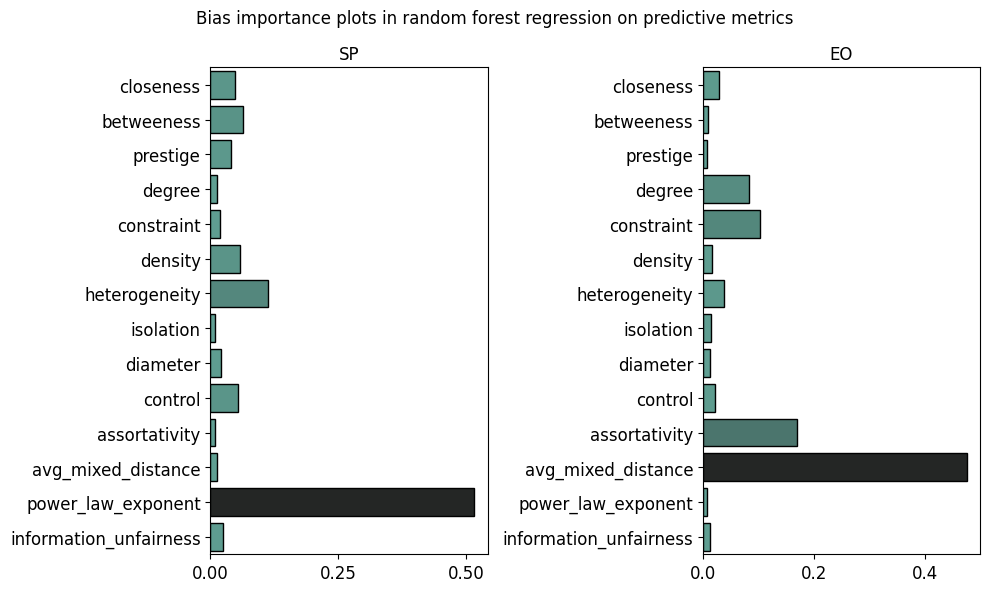

In [8]:
importance_plots(df)